# Lab DL 11: GAN untuk Image Generation
Nama :  Rahman Nendhairto

NIM  :  2200018315

# **1. Pendahuluan**

---
## GAN Networks

In a GAN, we build two different neural networks.

Our first network is a traditional classification network, called the **DISCRIMINATOR**. We will train the discriminator to take images, and classify them as being real (belonging to the training set) or fake (not present in the training set).

Our other network, called the **GENERATOR**, will take random noise as input and transform it using a neural network to produce images. The goal of the generator is to fool the discriminator into thinking the images it produced are real.

<center>
<img src="https://i.ibb.co/4RyZ2Vr/gan-en.png" width=80% />
</center>
<br>

We can think of this back and forth process of the generator ($G$) trying to fool the discriminator ($D$), and the discriminator trying to correctly classify real vs. fake as a minimax game:

$$\underset{G}{\text{minimize}}\; \underset{D}{\text{maximize}}\; \mathbb{E}_{x \sim p_\text{data}}\left[\log D(x)\right] + \mathbb{E}_{z \sim p(z)}\left[\log \left(1-D(G(z))\right)\right]$$
where
* $z \sim p(z)$ are the random noise samples,
* $G(z)$ are the generated images using the neural network generator $G$, and
* $D$ is the output of the discriminator, specifying the probability of an input being real.

<br>

In [Goodfellow et al.](https://arxiv.org/abs/1406.2661), they analyze this minimax game and show how it relates to minimizing the Jensen-Shannon divergence between the training data distribution and the generated samples from $G$.

# **2. Mounting Google Drive**

In [ ]:
from google.colab import drive

# mounting dataset dari gdrive
drive.mount('/content/gdrive', force_remount=True)

# lokasi dataset - ubah sesuai dengan lokasi anda mengupload folder datanya
# folder ini juga digunakan untuk menyimpan model yang sudah dilatih
root_path = 'gdrive/My Drive/Deep Learning Labs/LabDL11 Data/'

# opsional - tampilkan info lokasi dataset
print("Path root:", root_path)

Mounted at /content/gdrive
Path root: gdrive/My Drive/Deep Learning Labs/LabDL11 Data/


# **3. Download Dataset**
Download dataset dan simpan di gdrive yang sudah disediakan.
Kita menggunakan MNIST digit dataset

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical

import os, time, glob, imageio, PIL, pathlib
from IPython.display import Image

os.chdir(root_path)
if not os.path.exists('imgs'):
    os.mkdir('imgs')

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = np.concatenate([X_train, X_test])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Normalisasi data latih

In [ ]:
X_train = (X_train.astype(np.float32) - 127.5)/127.5
X_train = X_train[:, :, :, None]

# **4. Fungsi untuk Mengolah Dataset**
Fungsi untuk mengolah dataset

In [ ]:
def combine_images(images):
    num = images.shape[0]
    width = int(np.sqrt(num))
    height = int(np.ceil(float(num)/width))
    shape = images.shape[1:3]
    image = np.zeros((height*shape[0], width*shape[1]),
                     dtype=images.dtype)
    for index, img in enumerate(images):
        i = int(index/width)
        j = index % width
        image[i*shape[0]:(i+1)*shape[0], j*shape[1]:(j+1)*shape[1]] = \
            img[:, :, 0]
    image = image*127.5+127.5

    return image

def generate_images(generator, batch_size, sampling='normal'):

    z_size = generator.input_shape[1]
    if sampling == 'normal':
        noise = tf.random.normal(shape=(batch_size, z_size))
    else:
        noise = tf.random.uniform(shape=(batch_size, z_size), minval=-1, maxval=1)

    generated_images = generator.predict(noise, verbose=1)

    image = combine_images(generated_images)

    filename = "generated_image.png"
    PIL.Image.fromarray(image.astype(np.uint8)).save(filename)

    return image

def generate_best_images(generator, discriminator, batch_size, sampling='normal', tries=20):

    z_size = generator.input_shape[1]
    if sampling == 'normal':
        noise = tf.random.normal(shape=(batch_size*tries, z_size))
    else:
        noise = tf.random.uniform(shape=(batch_size, z_size), minval=-1, maxval=1)


    generated_images = generator.predict(noise, verbose=0)
    d_pret = discriminator.predict(generated_images, verbose=0)

    index = np.arange(0, batch_size*tries)
    index.resize((batch_size*tries, 1))

    pre_with_index = list(np.append(d_pret, index, axis=1))
    pre_with_index.sort(key=lambda x: x[0], reverse=True)

    nice_images = np.zeros((batch_size,) + generated_images.shape[1:3], dtype=np.float32)
    nice_images = nice_images[:, :, :, None]

    for i in range(batch_size):
        idx = int(pre_with_index[i][1])
        nice_images[i, :, :, 0] = generated_images[idx, :, :, 0]

    image = combine_images(nice_images)

    filename = "generated_image_best.png"
    PIL.Image.fromarray(image.astype(np.uint8)).save(filename)

    return image

def show_gif(base_dir, anim_file):

    with imageio.get_writer(anim_file, mode='I') as writer:
        filenames = glob.glob(base_dir+'/image*.png')
        filenames = sorted(filenames)
        for filename in filenames:
            image = imageio.imread(filename)
            for i in range(3):
                writer.append_data(image)
        image = imageio.imread(filename)
        writer.append_data(image)

    print('GIF saved as', anim_file)

    with open(anim_file,'rb') as f:
        display(Image(data=f.read(), format='png'))

# **5. Membangun Model GAN**

---
# [Part 1] GAN Training
Inside the training loop, there are basically three steps to train GANs.


<center>
<img src="https://i.ibb.co/Y388bJb/gan-steps-en.png" width=80% />
</center>
<br>

First, in each iteration, we use the current Generator to generate new batch of fake data from random latent space. Then the second is we use the generated batch along with a real batch of data to train one step of the Discriminator Model (one time forward and backward pass). The objective here is to minimize the binary crossentropy loss between the fake and real class.

The last is to train the Generator Model by feeding in a batch of random latent space to generate a batch of fake data (forward pass). The batch of fake data then feed into the trained Discriminator from previous step (forward pass). The objective here is to maximize the wrongly classified data, which we can turn into minimizing correctly classified data. The loss is then used to update **ONLY** the Generator Model's weights (backward pass)


---
##1 - Define Models

As mentioned before, there are two networks inside GAN, namely Generator and Discriminator.

As a side note, The rectified linear activation unit, or ReLU for short, is a simple calculation that returns the value provided as input directly, or the value 0.0 if the input is 0.0 or less.

It has become a best practice when developing deep convolutional neural networks generally, which it's also implemented in this exmaple.

However, best practice for GANs is to use a variation of the ReLU that allows some values less than zero and learns where the cut-off should be in each node. This is called the leaky rectified linear activation unit, or LeakyReLU for short. You can try and change the activation function yourself.


### Generator Model

The generator model must generate an output image given as input at a random point from the latent space.

The recommended approach for achieving this is to use a transpose convolutional layer with a strided convolution. This is a special type of layer that performs the convolution operation in reverse.

Intuitively, this means that setting a stride of $2×2$ will have the opposite effect, upsampling the input instead of downsampling it in the case of a normal convolutional layer.


<center>
<img src="https://i.ibb.co/s2gX3jR/generator1.png" width=70% />
</center>


By stacking a transpose convolutional layer with strided convolutions, the generator model is able to scale a given input to the desired output dimensions. It is also recommended in using Batch Normalization to standardizes the activations from a prior layer to have a zero mean and unit variance. This has the effect of stabilizing the training process.

## 5.1. Generator Model

In [ ]:
def generator_model(latent_dim = 128):
    model = Sequential([
        Dense(1024, input_dim=latent_dim, activation='relu'),
        BatchNormalization(),
        Dense(7 * 7 * 128, activation='relu'),
        Reshape((7, 7, 128)),
        Conv2DTranspose(64, (5, 5), strides=(2,2), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2DTranspose(1, (5, 5), strides=(2,2), padding='same', activation='tanh'),
    ])
    return model

generator_model().summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       132,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │     6,428,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,771,713 (25.83 MB)

 Trainable params: 6,769,537 (25.82 MB)

 Non-trainable params: 2,176 (8.50 KB)

### Discriminator Model

The discriminator model is a standard convolutional neural network model that takes an image as input and must output a binary classification as to whether it is real or fake.


<center>
<img src="https://i.ibb.co/nnxBg8S/discriminator1.png" width=70% />
</center>


It is standard practice with deep convolutional networks to use pooling layers to downsample the input and feature maps with the depth of the network, like implemented below.

However, turns out this is not recommended for the DCGAN, and instead, they recommend downsampling using strided convolutions. You can try and change the `maxpool` below using strided convolution yourself.

## 5.2. Discriminator Model

In [ ]:
def discriminator_model():
    model = Sequential([
        Conv2D(32, (5, 5), input_shape=(28, 28, 1), padding='same'),
        LeakyReLU(alpha=0.01),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (5, 5)),
        LeakyReLU(alpha=0.01),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(4 * 4 * 64, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
    return model

discriminator_model().summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,639,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,692,545 (6.46 MB)

 Trainable params: 1,692,545 (6.46 MB)

 Non-trainable params: 0 (0.00 B)

## 5.3. Gabungkan Kedua Model

In [ ]:
def combine_model(g, d):
    model = Sequential()
    model.add(g)
    model.add(d)
    return model

# **6. Pelatihan Model GAN**

---
## 2 - Training Functions

The latent space defines the shape and distribution of the input to the generator model used to generate new images.

The DCGAN recommends sampling from a uniform distribution, meaning that the shape of the latent space is a hypercube.

The more recent best practice is to sample from a standard Gaussian distribution, meaning that the shape of the latent space is a hypersphere, with a mean of zero and a standard deviation of one.

Tom White's [Sampling Generative Networks](https://arxiv.org/abs/1609.04468), ref code https://github.com/dribnet/plat has more details

---
The discriminator model is trained using stochastic gradient descent with mini-batches.

The best practice is to update the discriminator with separate batches of real and fake images rather than combining real and fake images into a single batch.

This can be achieved by updating the model weights for the discriminator model with two separate calls to the `train_on_batch()` function. You can try and change this yourself.

---
It is common to use the class label 1 to represent real images and class label 0 to represent fake images when training the discriminator model.

These are called hard labels, as the label values are precise or crisp.

It is a good practice to use soft labels as mentioned by Salimans et. al. 2016. Such values are slightly more or less than 1.0 or slightly more than 0.0 for real and fake images respectively, where the variation for each image is random.

This is often referred to as label noise or smoothing and can have a regularizing effect when training the model.

## 6.1. Fungsi Pelatihan

In [ ]:
def train_gan(X_train, Y_train,
              batch_size, epochs,
              models, sampling='normal',
              save_every=500, print_every=100):

    def sampling_fn(shape):
        if sampling == 'normal':
            return tf.random.normal(shape)
        else:
            return tf.random.uniform(shape, minval=-1, maxval=1)


    g, d, d_on_g = models


    print('Start training using random', sampling, 'distribution')
    print('Number of batches', int(X_train.shape[0]/batch_size))

    z_size = g.layers[0].input_shape[1]
    seed_saved = sampling_fn(shape=(16, z_size))
    img_count = 0

    start = time.time()

    for epoch in range(epochs):
        print("\n-------------------------------\nEpoch is", epoch)

        for index in range(int(X_train.shape[0]/batch_size)):

            noise = sampling_fn(shape=(batch_size, z_size))

            generated_images = g.predict(noise, verbose=0)

            image_batch = X_train[index*batch_size:(index+1)*batch_size]

            if index % save_every == 0:
                for_save = g.predict(seed_saved)
                image = combine_images(for_save)

                # simpan di folder gdrive imgs
                plt.imshow(image, cmap=plt.get_cmap('gray'))
                filename = 'imgs/image_'+'{:03}'.format(img_count)+'.png'
                plt.axis('off')
                plt.savefig(filename)
                plt.show()
                img_count += 1

            X = np.concatenate((image_batch, generated_images))
            y = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)
            y += 0.05 * tf.random.uniform(tf.shape(y))

            d_loss = d.train_on_batch(X, y)

            noise = sampling_fn(shape=(batch_size, z_size))

            d.trainable = False
            y = tf.ones((batch_size, 1))
            g_loss = d_on_g.train_on_batch(noise, y)

            if index % print_every == 0:
                print("batch %d, g_loss : %f, d_loss : %f" % (index, g_loss, d_loss))

            d.trainable = True

    end = time.time()

    print('Training ended in', (end-start)/60, 'minutes')
    models = [g, d, d_on_g]

    return models

In [ ]:
g_model = generator_model()
d_model = discriminator_model()

In [ ]:
d_optim = Adam(learning_rate=0.0003, beta_1=0.5)
g_optim = Adam(learning_rate=0.0003, beta_1=0.5)

d_model.trainable = False
d_on_g = combine_model(g_model, d_model)
d_on_g.compile(loss='binary_crossentropy', optimizer=g_optim)

d_model.trainable = True
d_model.compile(loss='binary_crossentropy', optimizer=d_optim)

models = [g_model, d_model, d_on_g]

## 6.2. Pelatihan GAN

Start training using random normal distribution
Number of batches 311

-------------------------------
Epoch is 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step


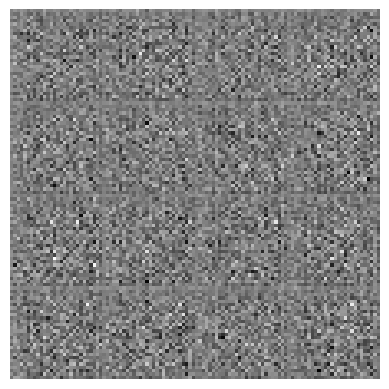

batch 0, g_loss : 0.165552, d_loss : 0.653197
batch 100, g_loss : 0.242712, d_loss : -0.445330
batch 200, g_loss : 6.641738, d_loss : -0.558542
batch 300, g_loss : 5.734414, d_loss : -0.384096

-------------------------------
Epoch is 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


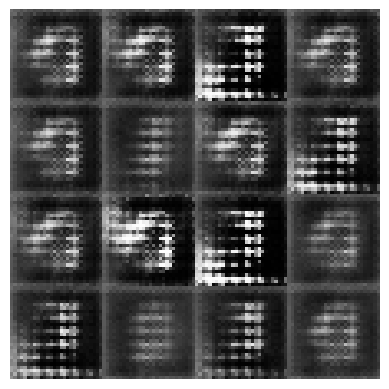

batch 0, g_loss : 5.538013, d_loss : -0.378890
batch 100, g_loss : 4.889266, d_loss : -0.200122
batch 200, g_loss : 4.346864, d_loss : -0.103206
batch 300, g_loss : 3.976455, d_loss : 0.003055

-------------------------------
Epoch is 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


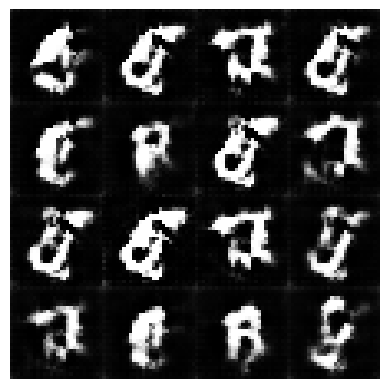

batch 0, g_loss : 3.936935, d_loss : 0.013929
batch 100, g_loss : 3.655642, d_loss : 0.079237
batch 200, g_loss : 3.420366, d_loss : 0.129829
batch 300, g_loss : 3.224409, d_loss : 0.170755

-------------------------------
Epoch is 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


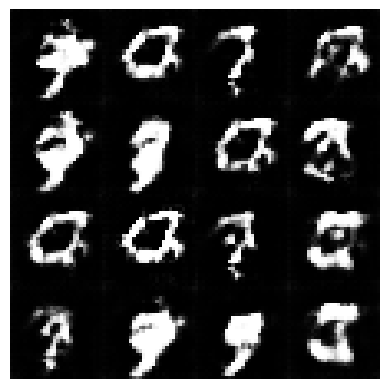

batch 0, g_loss : 3.204013, d_loss : 0.174386
batch 100, g_loss : 3.035730, d_loss : 0.211157
batch 200, g_loss : 2.888249, d_loss : 0.236961
batch 300, g_loss : 2.762446, d_loss : 0.264188

-------------------------------
Epoch is 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


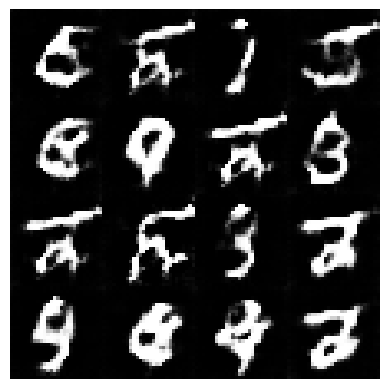

batch 0, g_loss : 2.749235, d_loss : 0.265844
batch 100, g_loss : 2.639307, d_loss : 0.286046
batch 200, g_loss : 2.542557, d_loss : 0.300789
batch 300, g_loss : 2.459954, d_loss : 0.313318

-------------------------------
Epoch is 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


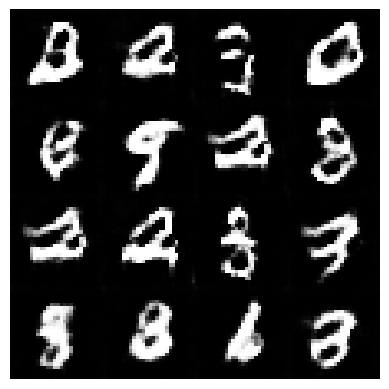

batch 0, g_loss : 2.452754, d_loss : 0.315066
batch 100, g_loss : 2.378756, d_loss : 0.328244
batch 200, g_loss : 2.315096, d_loss : 0.339369
batch 300, g_loss : 2.257498, d_loss : 0.351121

-------------------------------
Epoch is 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


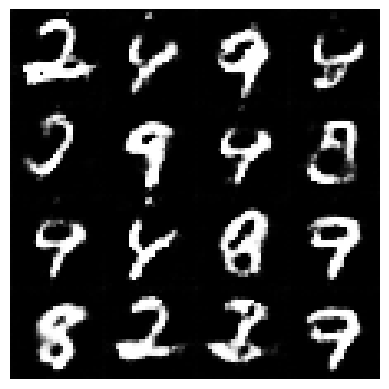

batch 0, g_loss : 2.251992, d_loss : 0.352037
batch 100, g_loss : 2.200841, d_loss : 0.360682
batch 200, g_loss : 2.151626, d_loss : 0.367192
batch 300, g_loss : 2.107633, d_loss : 0.375204

-------------------------------
Epoch is 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


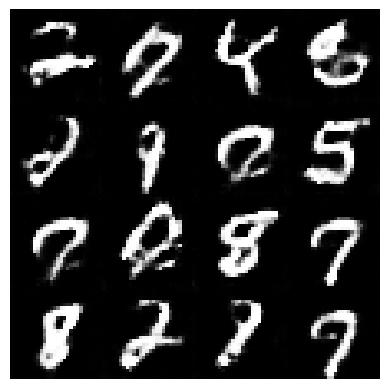

batch 0, g_loss : 2.102992, d_loss : 0.376126
batch 100, g_loss : 2.061389, d_loss : 0.383436
batch 200, g_loss : 2.021202, d_loss : 0.389709
batch 300, g_loss : 1.983737, d_loss : 0.396024

-------------------------------
Epoch is 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


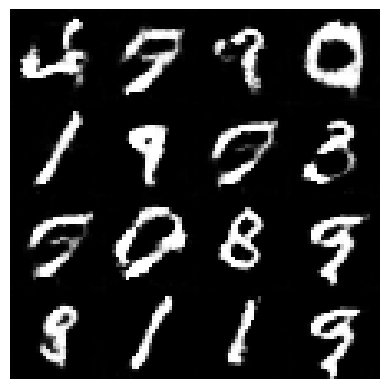

batch 0, g_loss : 1.980064, d_loss : 0.396604
batch 100, g_loss : 1.949820, d_loss : 0.400639
batch 200, g_loss : 1.922180, d_loss : 0.405638
batch 300, g_loss : 1.895897, d_loss : 0.410590

-------------------------------
Epoch is 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


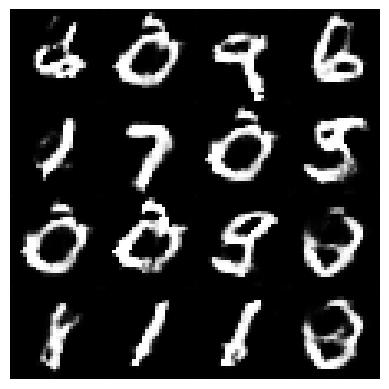

batch 0, g_loss : 1.893083, d_loss : 0.411291
batch 100, g_loss : 1.865361, d_loss : 0.416059
batch 200, g_loss : 1.839828, d_loss : 0.418809
batch 300, g_loss : 1.816776, d_loss : 0.422102

-------------------------------
Epoch is 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


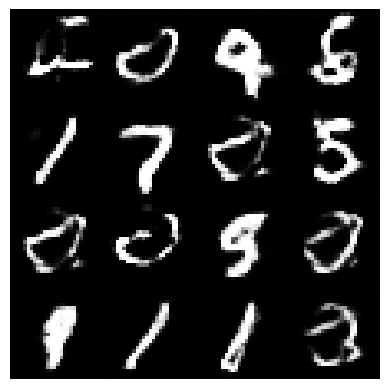

batch 0, g_loss : 1.814536, d_loss : 0.422532
batch 100, g_loss : 1.792021, d_loss : 0.426125
batch 200, g_loss : 1.770359, d_loss : 0.428845
batch 300, g_loss : 1.750917, d_loss : 0.431648

-------------------------------
Epoch is 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


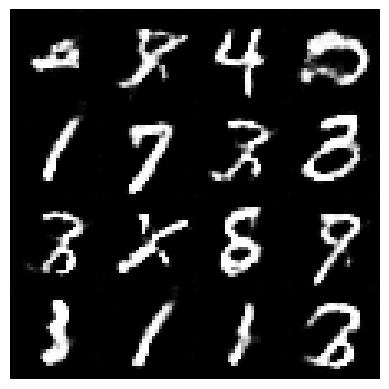

batch 0, g_loss : 1.749171, d_loss : 0.432090
batch 100, g_loss : 1.731844, d_loss : 0.434049
batch 200, g_loss : 1.714678, d_loss : 0.434583
batch 300, g_loss : 1.699060, d_loss : 0.435947

-------------------------------
Epoch is 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


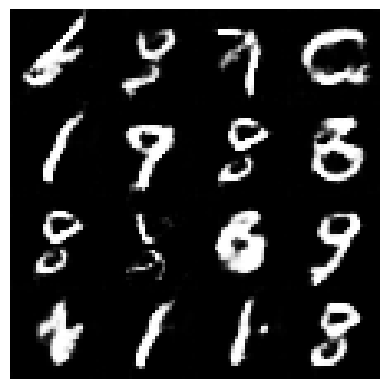

batch 0, g_loss : 1.697737, d_loss : 0.436203
batch 100, g_loss : 1.682503, d_loss : 0.437812
batch 200, g_loss : 1.668418, d_loss : 0.439380
batch 300, g_loss : 1.654945, d_loss : 0.441148

-------------------------------
Epoch is 13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


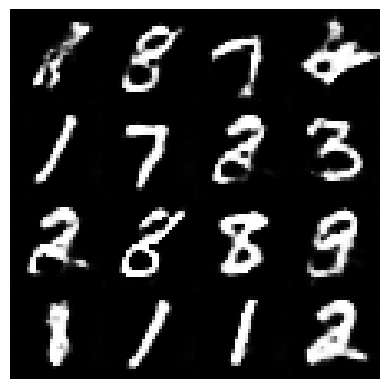

batch 0, g_loss : 1.653662, d_loss : 0.441408
batch 100, g_loss : 1.640378, d_loss : 0.442807
batch 200, g_loss : 1.628514, d_loss : 0.444152
batch 300, g_loss : 1.617182, d_loss : 0.445615

-------------------------------
Epoch is 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


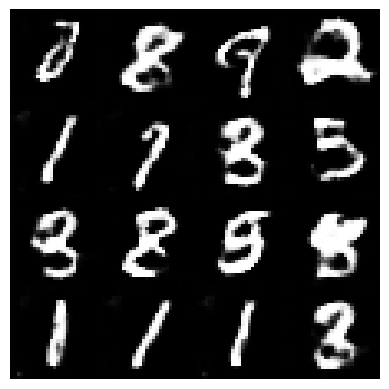

batch 0, g_loss : 1.616168, d_loss : 0.445817
batch 100, g_loss : 1.605531, d_loss : 0.445998
batch 200, g_loss : 1.590171, d_loss : 0.438890
batch 300, g_loss : 1.593177, d_loss : 0.425993

-------------------------------
Epoch is 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


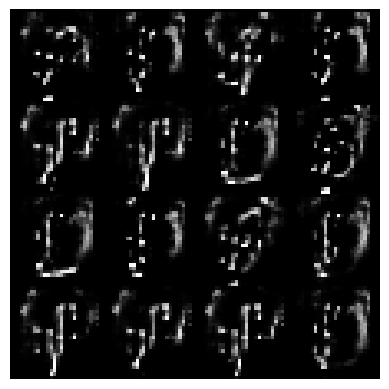

batch 0, g_loss : 1.593183, d_loss : 0.424239
batch 100, g_loss : 1.620840, d_loss : 0.407706
batch 200, g_loss : 1.660415, d_loss : 0.405061
batch 300, g_loss : 1.667365, d_loss : 0.402779

-------------------------------
Epoch is 16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


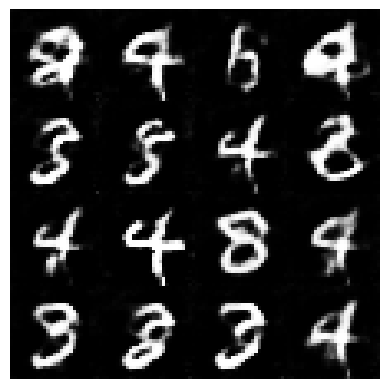

batch 0, g_loss : 1.667403, d_loss : 0.402433
batch 100, g_loss : 1.663727, d_loss : 0.398201
batch 200, g_loss : 1.664757, d_loss : 0.395463
batch 300, g_loss : 1.660246, d_loss : 0.392531

-------------------------------
Epoch is 17
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


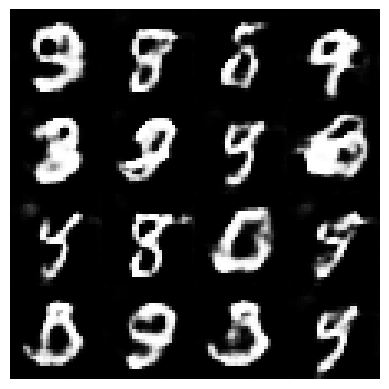

batch 0, g_loss : 1.660982, d_loss : 0.392354
batch 100, g_loss : 1.661966, d_loss : 0.389620
batch 200, g_loss : 1.659320, d_loss : 0.388339
batch 300, g_loss : 1.656982, d_loss : 0.387623

-------------------------------
Epoch is 18
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


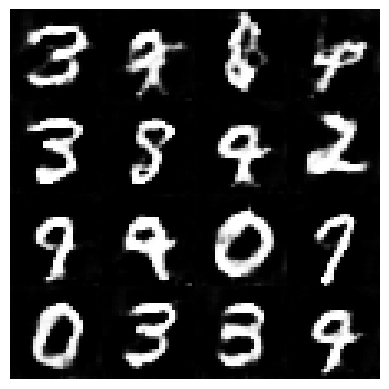

batch 0, g_loss : 1.656883, d_loss : 0.387575
batch 100, g_loss : 1.653839, d_loss : 0.386396
batch 200, g_loss : 1.651533, d_loss : 0.385802
batch 300, g_loss : 1.649922, d_loss : 0.385457

-------------------------------
Epoch is 19
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


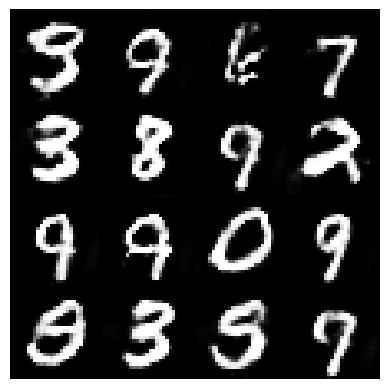

batch 0, g_loss : 1.649951, d_loss : 0.385459
batch 100, g_loss : 1.648799, d_loss : 0.385204
batch 200, g_loss : 1.646951, d_loss : 0.384448
batch 300, g_loss : 1.643179, d_loss : 0.383974

-------------------------------
Epoch is 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


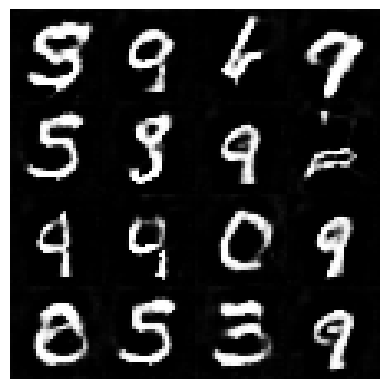

batch 0, g_loss : 1.643380, d_loss : 0.383774
batch 100, g_loss : 1.632011, d_loss : 0.380520
batch 200, g_loss : 1.622969, d_loss : 0.371316
batch 300, g_loss : 1.656648, d_loss : 0.361625

-------------------------------
Epoch is 21
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


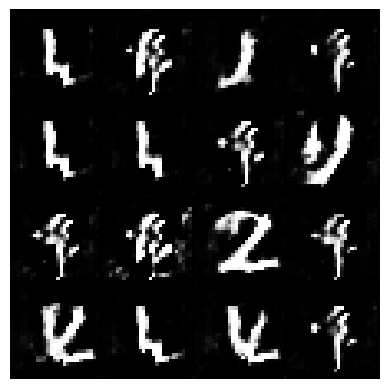

batch 0, g_loss : 1.657015, d_loss : 0.360985
batch 100, g_loss : 1.662244, d_loss : 0.356222
batch 200, g_loss : 1.663543, d_loss : 0.351673
batch 300, g_loss : 1.680406, d_loss : 0.348187

-------------------------------
Epoch is 22
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


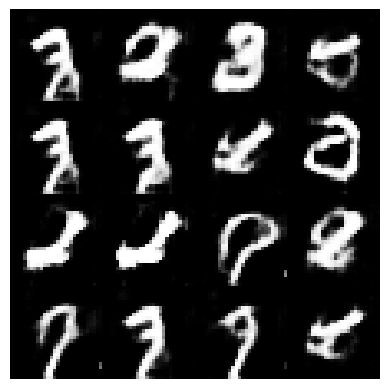

batch 0, g_loss : 1.680656, d_loss : 0.347968
batch 100, g_loss : 1.679634, d_loss : 0.345149
batch 200, g_loss : 1.683436, d_loss : 0.342286
batch 300, g_loss : 1.685894, d_loss : 0.339985

-------------------------------
Epoch is 23
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


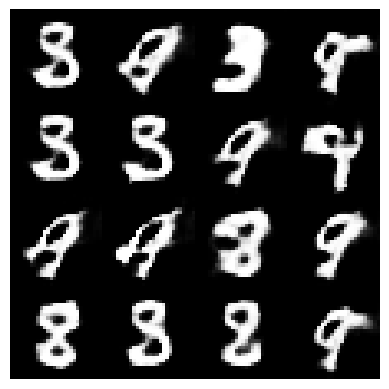

batch 0, g_loss : 1.686835, d_loss : 0.339719
batch 100, g_loss : 1.694988, d_loss : 0.337323
batch 200, g_loss : 1.698994, d_loss : 0.335094
batch 300, g_loss : 1.711003, d_loss : 0.332355

-------------------------------
Epoch is 24
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


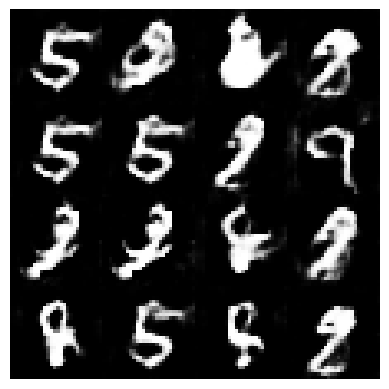

batch 0, g_loss : 1.711891, d_loss : 0.332200
batch 100, g_loss : 1.715029, d_loss : 0.329571
batch 200, g_loss : 1.720138, d_loss : 0.326952
batch 300, g_loss : 1.725112, d_loss : 0.323910

-------------------------------
Epoch is 25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


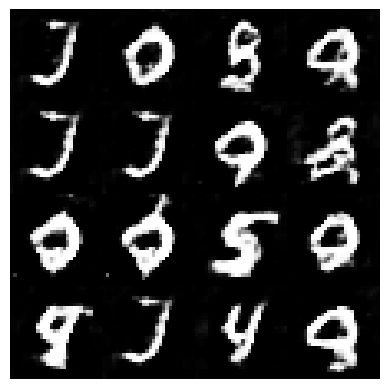

batch 0, g_loss : 1.726117, d_loss : 0.323532
batch 100, g_loss : 1.729255, d_loss : 0.320418
batch 200, g_loss : 1.726247, d_loss : 0.317994
batch 300, g_loss : 1.729448, d_loss : 0.315560

-------------------------------
Epoch is 26
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


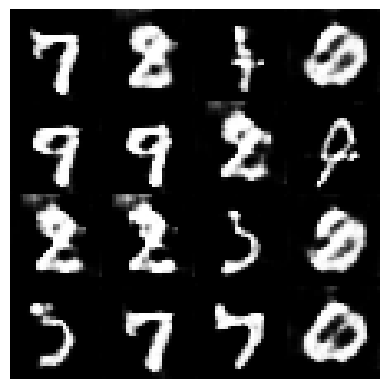

batch 0, g_loss : 1.730392, d_loss : 0.315418
batch 100, g_loss : 1.731461, d_loss : 0.312868
batch 200, g_loss : 1.727691, d_loss : 0.310233
batch 300, g_loss : 1.732049, d_loss : 0.308066

-------------------------------
Epoch is 27
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


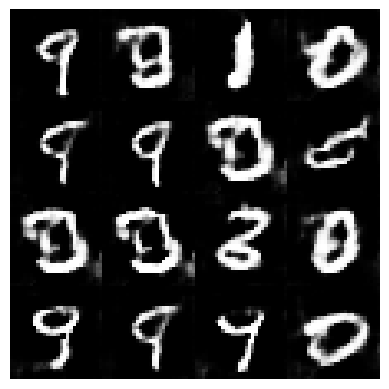

batch 0, g_loss : 1.732787, d_loss : 0.307841
batch 100, g_loss : 1.730391, d_loss : 0.305515
batch 200, g_loss : 1.731721, d_loss : 0.302995
batch 300, g_loss : 1.733770, d_loss : 0.300154

-------------------------------
Epoch is 28
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


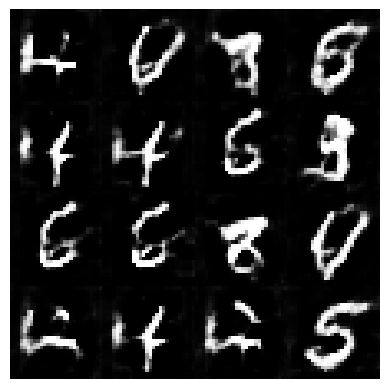

batch 0, g_loss : 1.734147, d_loss : 0.299876
batch 100, g_loss : 1.735070, d_loss : 0.296578
batch 200, g_loss : 1.729089, d_loss : 0.292788
batch 300, g_loss : 1.732168, d_loss : 0.289642

-------------------------------
Epoch is 29
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


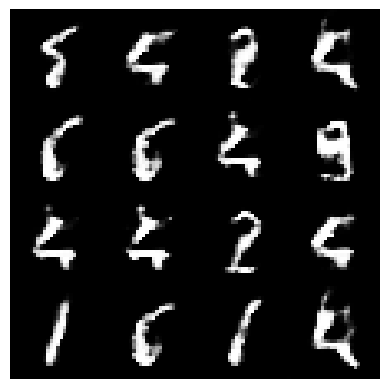

batch 0, g_loss : 1.732608, d_loss : 0.289279
batch 100, g_loss : 1.726594, d_loss : 0.284327
batch 200, g_loss : 1.728712, d_loss : 0.279979
batch 300, g_loss : 1.734084, d_loss : 0.275337

-------------------------------
Epoch is 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


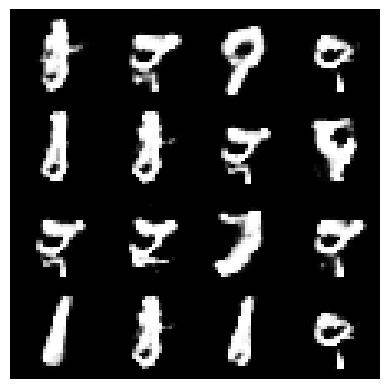

batch 0, g_loss : 1.734335, d_loss : 0.275076
batch 100, g_loss : 1.733874, d_loss : 0.272537
batch 200, g_loss : 1.727553, d_loss : 0.268932
batch 300, g_loss : 1.731407, d_loss : 0.263842

-------------------------------
Epoch is 31
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


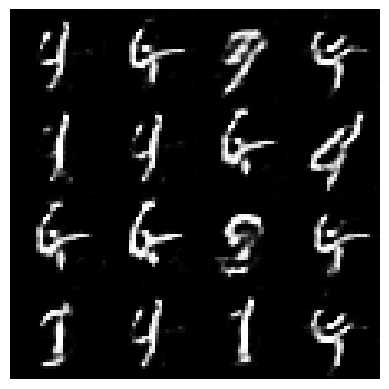

batch 0, g_loss : 1.732066, d_loss : 0.262962
batch 100, g_loss : 1.742613, d_loss : 0.258360
batch 200, g_loss : 1.747742, d_loss : 0.256280
batch 300, g_loss : 1.748347, d_loss : 0.255069

-------------------------------
Epoch is 32
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


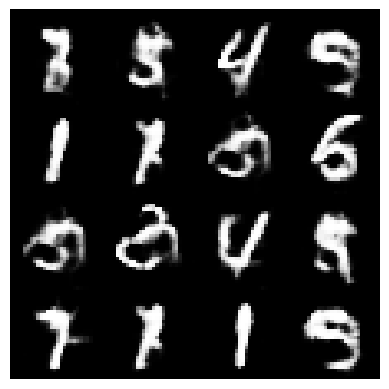

batch 0, g_loss : 1.749007, d_loss : 0.254980
batch 100, g_loss : 1.749651, d_loss : 0.253408
batch 200, g_loss : 1.749062, d_loss : 0.251179
batch 300, g_loss : 1.752948, d_loss : 0.249682

-------------------------------
Epoch is 33
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


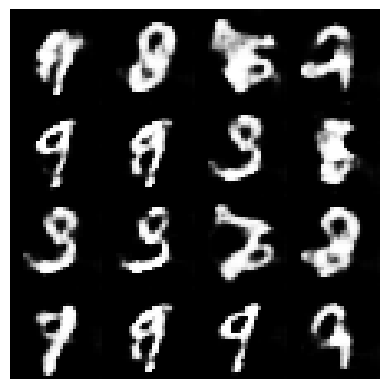

batch 0, g_loss : 1.753220, d_loss : 0.249489
batch 100, g_loss : 1.755450, d_loss : 0.247622
batch 200, g_loss : 1.757626, d_loss : 0.245909
batch 300, g_loss : 1.758498, d_loss : 0.243766

-------------------------------
Epoch is 34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


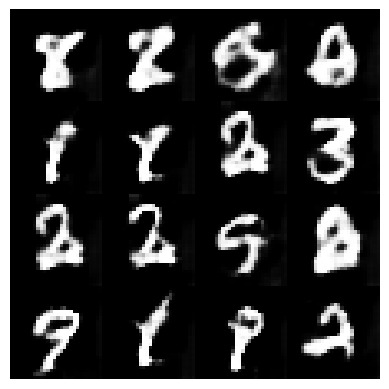

batch 0, g_loss : 1.758947, d_loss : 0.243650
batch 100, g_loss : 1.763628, d_loss : 0.241855
batch 200, g_loss : 1.763836, d_loss : 0.240253
batch 300, g_loss : 1.764529, d_loss : 0.238557

-------------------------------
Epoch is 35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


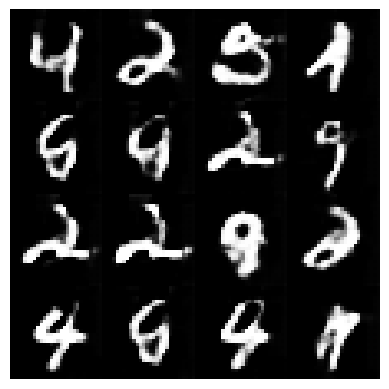

batch 0, g_loss : 1.764717, d_loss : 0.238348
batch 100, g_loss : 1.770408, d_loss : 0.236277
batch 200, g_loss : 1.778047, d_loss : 0.233912
batch 300, g_loss : 1.781586, d_loss : 0.231297

-------------------------------
Epoch is 36
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


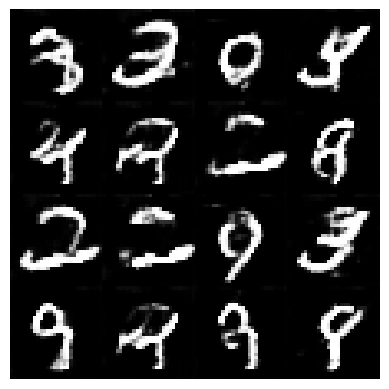

batch 0, g_loss : 1.783272, d_loss : 0.230979
batch 100, g_loss : 1.792582, d_loss : 0.228289
batch 200, g_loss : 1.799439, d_loss : 0.226194
batch 300, g_loss : 1.805463, d_loss : 0.224709

-------------------------------
Epoch is 37
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


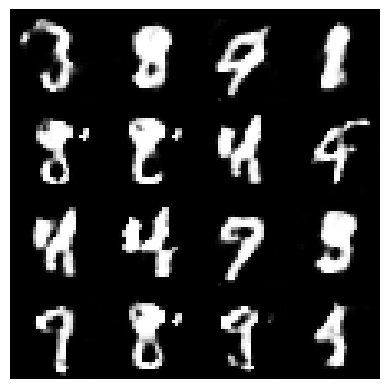

batch 0, g_loss : 1.806142, d_loss : 0.224454
batch 100, g_loss : 1.811164, d_loss : 0.222966
batch 200, g_loss : 1.814580, d_loss : 0.221253
batch 300, g_loss : 1.821712, d_loss : 0.219605

-------------------------------
Epoch is 38
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


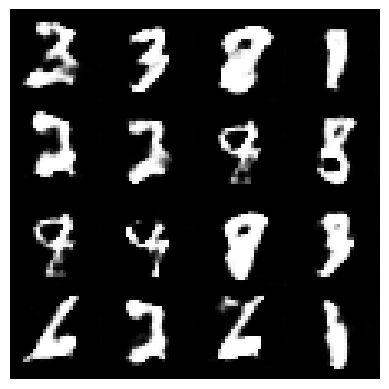

batch 0, g_loss : 1.822852, d_loss : 0.219616
batch 100, g_loss : 1.826577, d_loss : 0.217243
batch 200, g_loss : 1.827673, d_loss : 0.213712
batch 300, g_loss : 1.836345, d_loss : 0.211320

-------------------------------
Epoch is 39
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


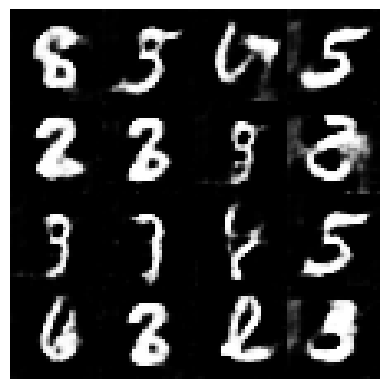

batch 0, g_loss : 1.836951, d_loss : 0.211117
batch 100, g_loss : 1.839031, d_loss : 0.209438
batch 200, g_loss : 1.842184, d_loss : 0.208060
batch 300, g_loss : 1.844354, d_loss : 0.205791

-------------------------------
Epoch is 40
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


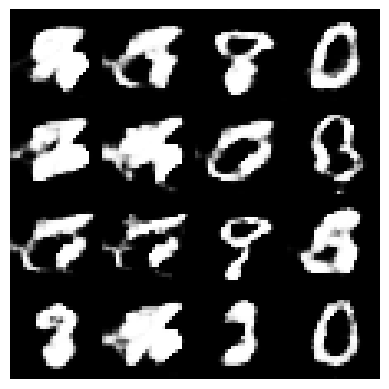

batch 0, g_loss : 1.844795, d_loss : 0.205522
batch 100, g_loss : 1.844751, d_loss : 0.203137
batch 200, g_loss : 1.844113, d_loss : 0.200343
batch 300, g_loss : 1.845826, d_loss : 0.197221

-------------------------------
Epoch is 41
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


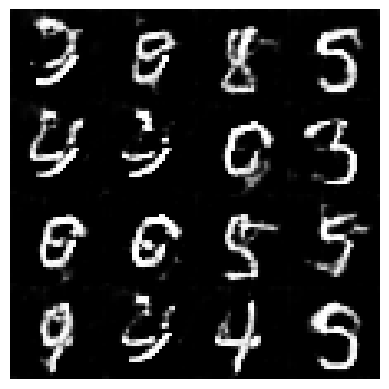

batch 0, g_loss : 1.847222, d_loss : 0.196789
batch 100, g_loss : 1.854206, d_loss : 0.194408
batch 200, g_loss : 1.858259, d_loss : 0.193177
batch 300, g_loss : 1.861522, d_loss : 0.191963

-------------------------------
Epoch is 42
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


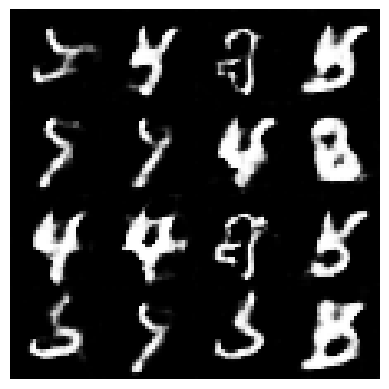

batch 0, g_loss : 1.862265, d_loss : 0.191743
batch 100, g_loss : 1.865678, d_loss : 0.190096
batch 200, g_loss : 1.871636, d_loss : 0.188735
batch 300, g_loss : 1.875103, d_loss : 0.186835

-------------------------------
Epoch is 43
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


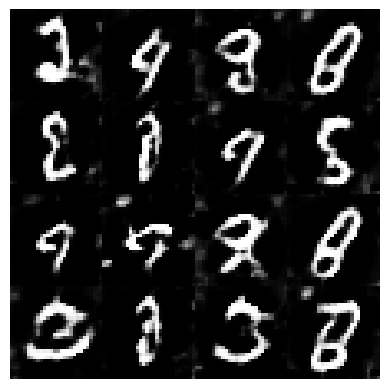

batch 0, g_loss : 1.874923, d_loss : 0.186666
batch 100, g_loss : 1.880810, d_loss : 0.184425
batch 200, g_loss : 1.886023, d_loss : 0.182182
batch 300, g_loss : 1.892169, d_loss : 0.180717

-------------------------------
Epoch is 44
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


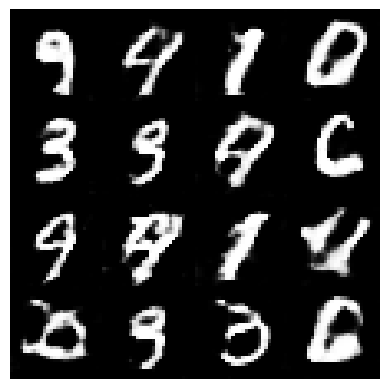

batch 0, g_loss : 1.892815, d_loss : 0.180587
batch 100, g_loss : 1.894068, d_loss : 0.179291
batch 200, g_loss : 1.900703, d_loss : 0.176729
batch 300, g_loss : 1.901399, d_loss : 0.174422

-------------------------------
Epoch is 45
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


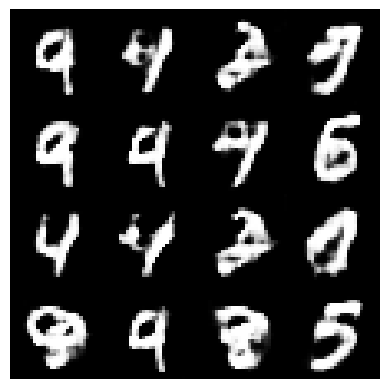

batch 0, g_loss : 1.901340, d_loss : 0.174237
batch 100, g_loss : 1.905631, d_loss : 0.171355
batch 200, g_loss : 1.907393, d_loss : 0.169255
batch 300, g_loss : 1.910703, d_loss : 0.166729

-------------------------------
Epoch is 46
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


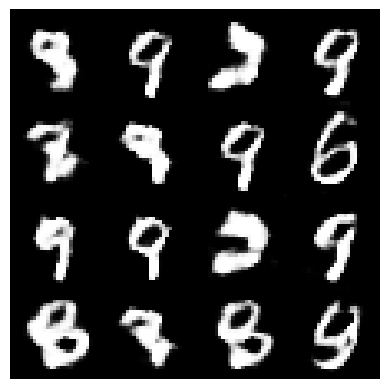

batch 0, g_loss : 1.910960, d_loss : 0.166421
batch 100, g_loss : 1.908365, d_loss : 0.163090
batch 200, g_loss : 1.919263, d_loss : 0.159814
batch 300, g_loss : 1.923096, d_loss : 0.157757

-------------------------------
Epoch is 47
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


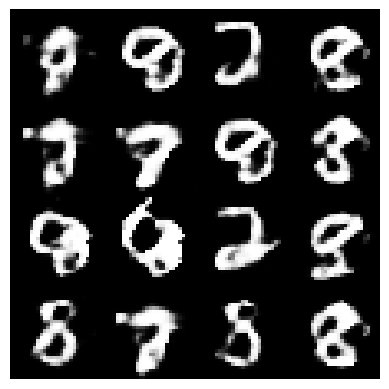

batch 0, g_loss : 1.923522, d_loss : 0.157609
batch 100, g_loss : 1.921621, d_loss : 0.155457
batch 200, g_loss : 1.928511, d_loss : 0.152681
batch 300, g_loss : 1.927818, d_loss : 0.149056

-------------------------------
Epoch is 48
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


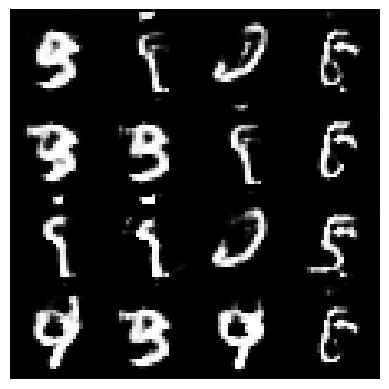

batch 0, g_loss : 1.929246, d_loss : 0.148792
batch 100, g_loss : 1.934643, d_loss : 0.146292
batch 200, g_loss : 1.935940, d_loss : 0.143943
batch 300, g_loss : 1.940511, d_loss : 0.141752

-------------------------------
Epoch is 49
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


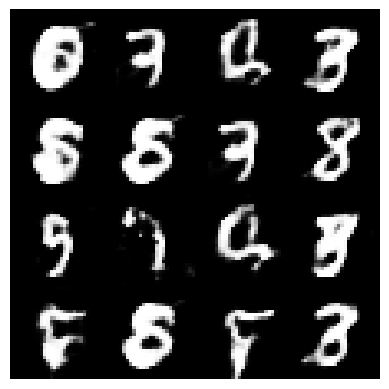

batch 0, g_loss : 1.940888, d_loss : 0.141588
batch 100, g_loss : 1.942009, d_loss : 0.139797
batch 200, g_loss : 1.944211, d_loss : 0.137937
batch 300, g_loss : 1.947079, d_loss : 0.136108
Training ended in 37.4617277264595 minutes


In [ ]:
batch = 225
epochs = 50
g_model, d_model, _ = train_gan(X_train, y_train, batch, epochs, models)

/tmp/ipython-input-4-1884257495.py:72: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
/tmp/ipython-input-4-1884257495.py:75: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


GIF saved as GAN.gif


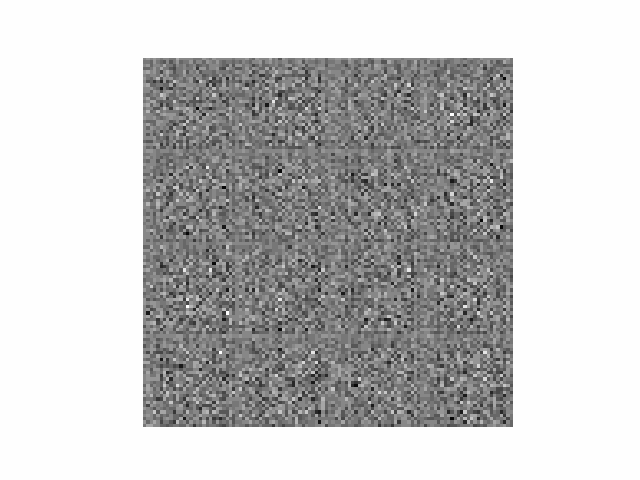

In [ ]:
show_gif('imgs', 'GAN.gif')

# **7. Evaluasi Model**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step


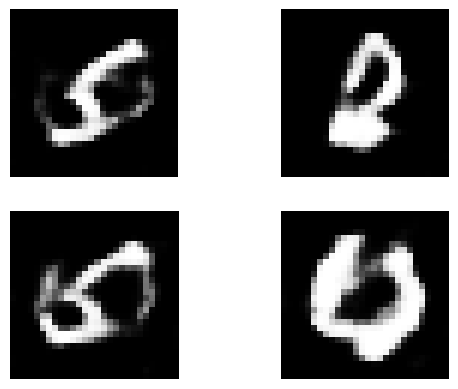

In [ ]:
seed = tf.random.normal(shape=(4, 128))
images = g_model.predict(seed)

for i in range(4):
    plt.subplot(2,2,1+i)
    plt.imshow(np.reshape(images[i], (28,28,)),cmap=plt.get_cmap('gray'))
    plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step


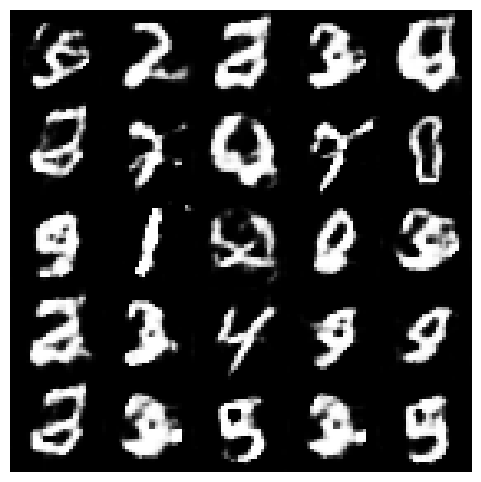

In [ ]:
images = generate_images(g_model, 25)
plt.figure(figsize = (6,6))
plt.imshow(images, cmap=plt.get_cmap('gray'))
plt.axis('off')
plt.show()

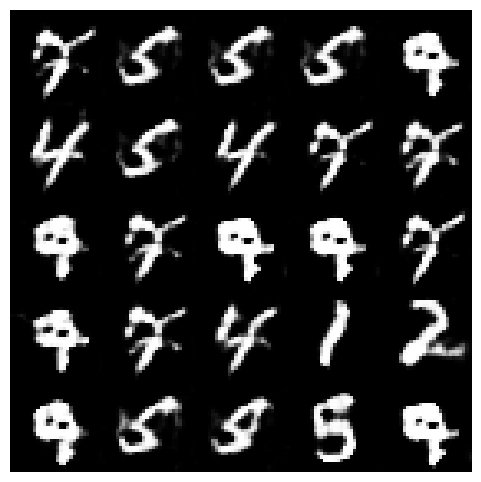

In [ ]:
images = generate_best_images(g_model, d_model, 25)
plt.figure(figsize = (6,6))
plt.imshow(images, cmap=plt.get_cmap('gray'))
plt.axis('off')
plt.show()